# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
311,0.096197,-0.044642,0.040140,-0.057313,0.045213,0.060690,-0.021311,0.036154,0.012551,0.023775,180.0
323,0.070769,0.050680,-0.007284,0.049415,0.060349,-0.004445,-0.054446,0.108111,0.129021,0.056912,248.0
306,0.009016,0.050680,-0.001895,0.021872,-0.038720,-0.024800,-0.006584,-0.039493,-0.039809,-0.013504,44.0
33,0.030811,-0.044642,-0.050396,-0.002228,-0.044223,-0.089935,0.118591,-0.076395,-0.018114,0.003064,87.0
351,-0.085430,0.050680,-0.040696,-0.033213,-0.081374,-0.069580,-0.006584,-0.039493,-0.057803,-0.042499,71.0
145,-0.041840,-0.044642,0.128521,0.063187,-0.033216,-0.032629,0.011824,-0.039493,-0.015999,-0.050783,259.0
201,-0.034575,0.050680,-0.055785,-0.015999,-0.009825,-0.007890,0.037595,-0.039493,-0.052963,0.027917,39.0
182,0.045341,0.050680,0.005650,0.056301,0.064477,0.089186,-0.039719,0.071210,0.015568,-0.009362,138.0
219,-0.089063,-0.044642,-0.041774,-0.019442,-0.066239,-0.074277,0.008142,-0.039493,0.001148,-0.030072,185.0
321,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054,230.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
missing_counts = data.isnull().sum().sort_values(ascending=False)

print("Valores faltantes por columna:")
display(missing_counts[missing_counts > 0])

Valores faltantes por columna:


bmi    44
bp     44
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
imputer_mean = SimpleImputer(strategy='mean')
data_simple = data.copy()
data_simple[['bmi']] = imputer_mean.fit_transform(data_simple[['bmi']])

print("Faltantes en 'bmi' después de imputación simple:", data_simple['bmi'].isna().sum())
print("Media usada para imputar:", round(data['bmi'].mean(), 6))

print("Muestra de filas imputadas en 'bmi':")
display(data_simple.loc[data['bmi'].isna(), ['bmi']].head())

Faltantes en 'bmi' después de imputación simple: 0
Media usada para imputar: -0.000205
Muestra de filas imputadas en 'bmi':


,bmi
9,-0.000205
30,-0.000205
39,-0.000205
55,-0.000205
70,-0.000205


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:
knn_imputer = KNNImputer(n_neighbors=5)
data_knn = data.copy()
data_knn[['bmi', 'bp']] = knn_imputer.fit_transform(data_knn[['bmi', 'bp']])

print("Faltantes tras KNNImputer:")
print(data_knn[['bmi', 'bp']].isna().sum())

comparison = pd.DataFrame({
    'bmi_original': data['bmi'],
    'bmi_simple': data_simple['bmi'],
    'bmi_knn': data_knn['bmi'],
    'bp_original': data['bp'],
    'bp_knn': data_knn['bp']
})

display(comparison.head(10))

Faltantes tras KNNImputer:
bmi    0
bp     0
dtype: int64


,bmi_original,bmi_simple,bmi_knn,bp_original,bp_knn
0,0.061696,0.061696,0.061696,0.021872,0.021872
1,-0.051474,-0.051474,-0.051474,NaN,0.003970
2,0.044451,0.044451,0.044451,-0.005670,-0.005670
3,-0.011595,-0.011595,-0.011595,-0.036656,-0.036656
4,-0.036385,-0.036385,-0.036385,0.021872,0.021872
5,-0.040696,-0.040696,-0.040696,-0.019442,-0.019442
6,-0.047163,-0.047163,-0.047163,-0.015999,-0.015999
7,-0.001895,-0.001895,-0.001895,0.066629,0.066629
8,0.061696,0.061696,0.061696,-0.040099,-0.040099
9,NaN,-0.000205,-0.016122,-0.033213,-0.033213


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

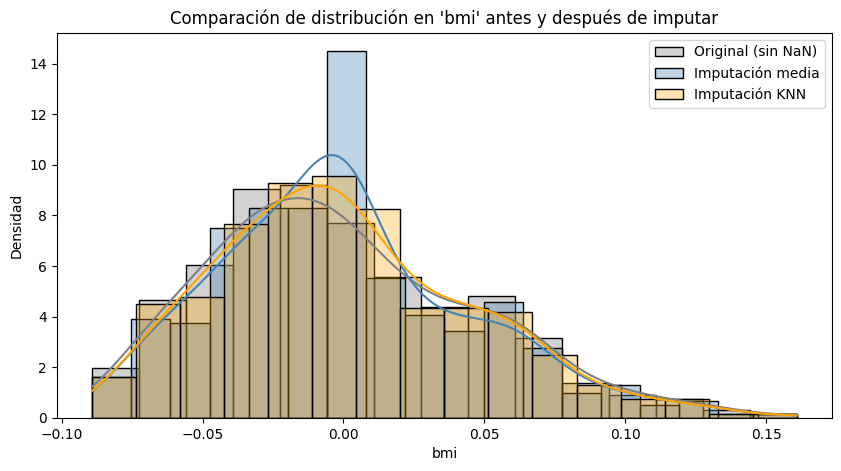

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data['bmi'].dropna(), color='gray', label='Original (sin NaN)', kde=True, stat='density', alpha=0.35)
sns.histplot(data_simple['bmi'], color='steelblue', label='Imputación media', kde=True, stat='density', alpha=0.35)
sns.histplot(data_knn['bmi'], color='orange', label='Imputación KNN', kde=True, stat='density', alpha=0.30)

plt.title("Comparación de distribución en 'bmi' antes y después de imputar")
plt.xlabel("bmi")
plt.ylabel("Densidad")
plt.legend()
plt.show()